Saved figure to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_prompt_distribution_over_iterations_2x4_regions_raw_smooth_font20_fixed.jpg


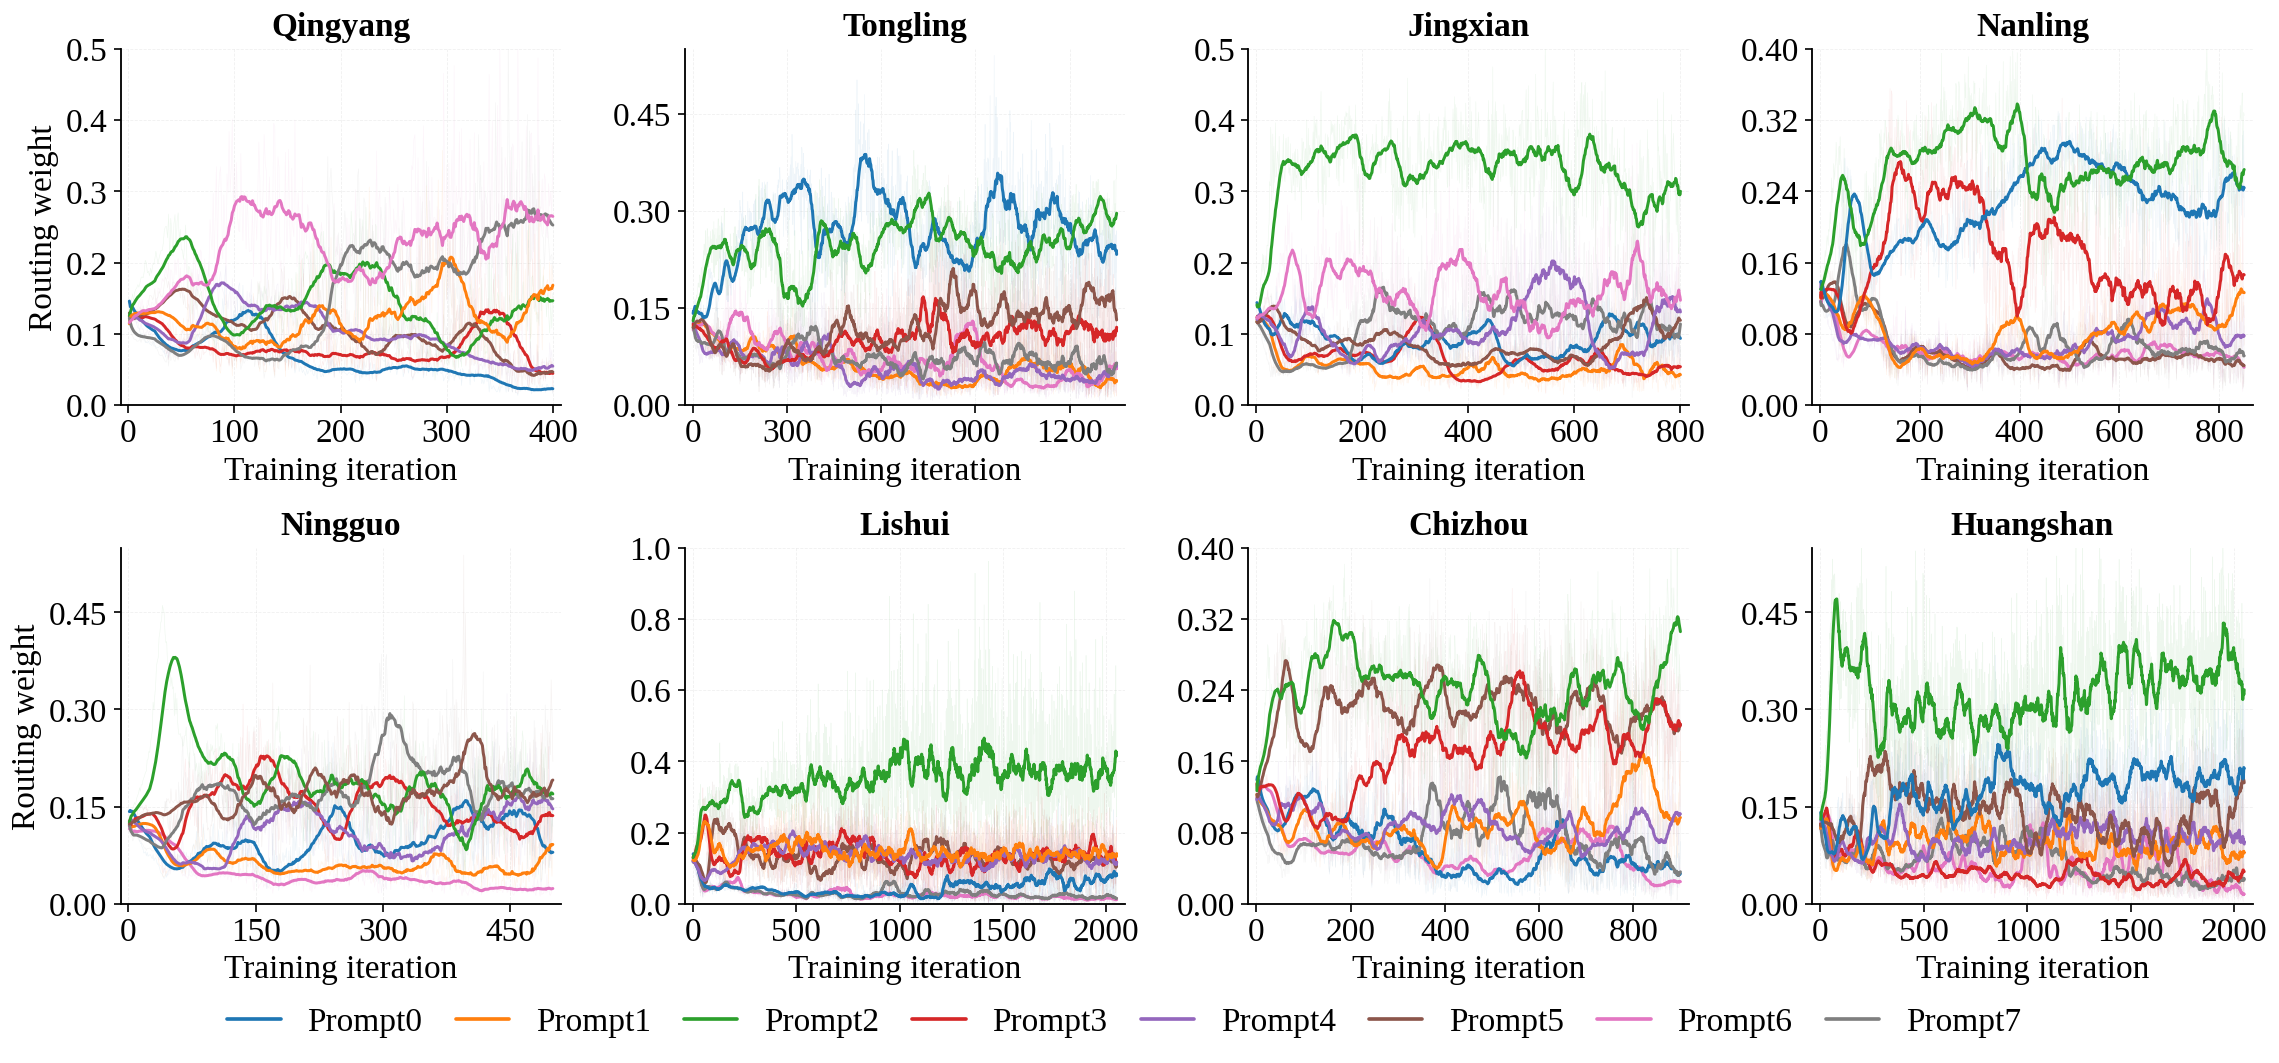

In [13]:




from pathlib import Path

import os

import math



import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from matplotlib.ticker import MaxNLocator





# =========================

# 0. Clear old figures

# =========================



plt.close("all")





# =========================

# 1. Configuration

# =========================



RUN_DIR = Path(

    "/home/ustc1958/lxy/graph/tone/complete_package0614/"

    "output/0614/hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps"

)



SETTING = "num_prompts_8"



OUTPUT_DIR = Path(

    "/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid"

)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



OUTPUT_PATH = OUTPUT_DIR / "fig_prompt_distribution_over_iterations_2x4_regions_raw_smooth_font20_fixed.jpg"



MPLCONFIGDIR = OUTPUT_DIR / ".matplotlib"

MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))





# =========================

# 2. Figure parameters

# =========================



SMOOTH_WINDOW = 25



# Jupyter 显示用 DPI，不要太大，否则容易卡住

FIG_DPI = 120



# 保存论文图用 DPI

SAVE_DPI = 300



# 字体为 20 时，不要用 24x12 + 300dpi 直接显示，会太重

FIGSIZE = (19.0, 9.5)



# 保留原始 routing weight 曲线

SHOW_RAW = True



RAW_ALPHA = 0.08

RAW_LW = 0.35

SMOOTH_LW = 1.80



# 所有字体统一 20

FONT_SIZE = 20



PANEL_FS = FONT_SIZE

TITLE_FS = FONT_SIZE

LABEL_FS = FONT_SIZE

TICK_FS = FONT_SIZE

LEGEND_FS = FONT_SIZE



REGIONS = [

    "Qingyang",

    "Tongling",

    "Jingxian",

    "Nanling",

    "Ningguo",

    "Lishui",

    "Chizhou",

    "Huangshan",

]



PROMPT_IDS = list(range(8))





# =========================

# 3. Fixed color mapping

# =========================



TAB10 = plt.get_cmap("tab10")

PROMPT_COLORS = {

    i: TAB10(i)

    for i in PROMPT_IDS

}





# =========================

# 4. Global plot style

# =========================



plt.rcParams.update({

    # 服务器更容易找到这个字体，避免 Times New Roman warning 刷屏

    "font.family": "serif",

    "font.serif": [

        "Liberation Serif",

        "DejaVu Serif",

    ],

    "mathtext.fontset": "stix",



    "font.size": FONT_SIZE,

    "axes.titlesize": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE,

    "ytick.labelsize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,



    "axes.linewidth": 1.1,

    "xtick.major.width": 1.0,

    "ytick.major.width": 1.0,

    "xtick.major.size": 4.5,

    "ytick.major.size": 4.5,



    "pdf.fonttype": 42,

    "ps.fonttype": 42,

})





# =========================

# 5. Helpers

# =========================



def smooth_series(series, window=SMOOTH_WINDOW):

    return series.rolling(window=window, min_periods=1).mean()





def load_curve(region):

    input_csv = RUN_DIR / SETTING / region / "curve.csv"



    if not input_csv.exists():

        raise FileNotFoundError(f"Missing curve file: {input_csv}")



    df = pd.read_csv(input_csv)



    for col in df.columns:

        df[col] = pd.to_numeric(df[col], errors="coerce")



    if "step" in df.columns:

        x_col = "step"

    elif "epoch" in df.columns:

        x_col = "epoch"

    else:

        raise ValueError(

            f"Neither 'step' nor 'epoch' exists in {input_csv}. "

            f"Available columns: {list(df.columns)}"

        )



    df = df.sort_values(x_col).reset_index(drop=True)



    prompt_cols = [

        col for col in df.columns

        if col.startswith("prompt_route_mean_")

    ]



    if not prompt_cols:

        raise ValueError(f"No prompt_route_mean_* columns found in {input_csv}")



    prompt_cols = [

        col for col in prompt_cols

        if int(col.split("_")[-1]) in PROMPT_IDS

    ]



    prompt_cols = sorted(

        prompt_cols,

        key=lambda c: int(c.split("_")[-1])

    )



    return df, x_col, prompt_cols





def get_plot_order(df, prompt_cols):

    final_smoothed_values = {

        col: smooth_series(df[col]).iloc[-1]

        for col in prompt_cols

    }



    return sorted(

        prompt_cols,

        key=lambda c: final_smoothed_values[c]

    )





def nice_upper_bound(v):

    if v <= 0.20:

        step = 0.02

    elif v <= 0.50:

        step = 0.05

    else:

        step = 0.10



    upper = math.ceil(v / step) * step

    upper += step

    upper = max(upper, 0.15)



    return upper





def compute_ymax(df, prompt_cols):

    smoothed_max = max(

        smooth_series(df[col]).max()

        for col in prompt_cols

    )



    raw_max = max(

        df[col].max()

        for col in prompt_cols

    )



    base = max(smoothed_max, raw_max * 0.85)



    return nice_upper_bound(base)





def plot_one_region(ax, region):

    df, x_col, prompt_cols = load_curve(region)

    plot_order = get_plot_order(df, prompt_cols)



    # =========================

    # Raw routing weight curves

    # =========================

    if SHOW_RAW:

        for col in plot_order:

            prompt_id = int(col.split("_")[-1])

            color = PROMPT_COLORS[prompt_id]



            ax.plot(

                df[x_col],

                df[col],

                linewidth=RAW_LW,

                alpha=RAW_ALPHA,

                color=color,

                zorder=1,

            )



    # =========================

    # Smoothed routing weight curves

    # =========================

    for col in plot_order:

        prompt_id = int(col.split("_")[-1])

        color = PROMPT_COLORS[prompt_id]



        ax.plot(

            df[x_col],

            smooth_series(df[col]),

            linewidth=SMOOTH_LW,

            color=color,

            zorder=3,

            solid_capstyle="round",

        )





    ax.set_title(

        region,

        fontsize=TITLE_FS,

        fontweight="bold",

        pad=8,

        loc="center",

    )



    ax.grid(

        True,

        linestyle="--",

        linewidth=0.50,

        alpha=0.18,

    )



    ymax = compute_ymax(df, prompt_cols)

    ax.set_ylim(0, ymax)



    ax.margins(x=0.02)



    for spine in ["top", "right"]:

        ax.spines[spine].set_visible(False)



    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))





# =========================

# 6. Plot

# =========================



fig, axes = plt.subplots(

    2,

    4,

    figsize=FIGSIZE,

    dpi=FIG_DPI,

)



axes_flat = axes.flatten()



for idx, (ax, region) in enumerate(zip(axes_flat, REGIONS)):

    plot_one_region(ax, region)



    row = idx // 4

    col = idx % 4



    if col == 0:

        ax.set_ylabel("Routing weight", fontsize=LABEL_FS)

    else:

        ax.set_ylabel("")





    ax.set_xlabel("Training iteration", fontsize=LABEL_FS)





    ax.tick_params(

        axis="both",

        labelsize=TICK_FS,

        width=1.0,

        length=4.5,

    )





# =========================

# 7. Global legend

# =========================



legend_handles = [

    Line2D(

        [0],

        [0],

        color=PROMPT_COLORS[i],

        lw=2.2,

        label=f"Prompt{i}",

        solid_capstyle="round",

    )

    for i in PROMPT_IDS

]



fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=8,   # 两排，每排 4 个
    frameon=False,
    fontsize=LEGEND_FS,
    handlelength=1.6,
    columnspacing=1.0,
    labelspacing=0.6,
    borderaxespad=0.2,
)





# =========================

# 8. Layout and save

# =========================



fig.subplots_adjust(
    left=0.060,
    right=0.995,
    bottom=0.15,   # 底部留给 legend
    top=0.900,
    wspace=0.28,
    hspace=0.4,
)


fig.savefig(

    OUTPUT_PATH,

    dpi=SAVE_DPI,

    bbox_inches="tight",

)



print(f"Saved figure to: {OUTPUT_PATH.resolve()}")



plt.show()

In [ ]:
from pathlib import Path

import os
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


# =========================
# 0. Clear old figures
# =========================

plt.close("all")


# =========================
# 1. Configuration
# =========================

RUN_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "output/0614/hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps"
)

# 保留原实验目录名，不影响绘图语义
SETTING = "num_prompts_8"

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "fig_layerwise_prompt_acoustic_interaction_2x4_regions_raw_smooth_font20.jpg"
)

# 建议同时保存 PDF 矢量图，用于 AAAI 论文
OUTPUT_PDF_PATH = (
    OUTPUT_DIR
    / "fig_layerwise_prompt_acoustic_interaction_2x4_regions_raw_smooth_font20.pdf"
)

MPLCONFIGDIR = OUTPUT_DIR / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))


# =========================
# 2. Figure parameters
# =========================

SMOOTH_WINDOW = 25

# Jupyter 显示用 DPI
FIG_DPI = 120

# 保存论文图用 DPI
SAVE_DPI = 300

FIGSIZE = (19.0, 9.5)

# 保留原始 Prompt–acoustic interaction 曲线
SHOW_RAW = True

RAW_ALPHA = 0.08
RAW_LW = 0.35
SMOOTH_LW = 1.80

# 所有字体统一 20
FONT_SIZE = 20

TITLE_FS = FONT_SIZE
LABEL_FS = FONT_SIZE
TICK_FS = FONT_SIZE
LEGEND_FS = FONT_SIZE

REGIONS = [
    "Qingyang",
    "Tongling",
    "Jingxian",
    "Nanling",
    "Ningguo",
    "Lishui",
    "Chizhou",
    "Huangshan",
]

# 最新版建议使用的 CSV 列名前缀：
# prompt_interaction_mean_0
# prompt_interaction_mean_1
# ...
#
# 为尽量少改旧实验结果，同时兼容旧列名：
# prompt_route_mean_0
# prompt_route_mean_1
# ...
NEW_COLUMN_PREFIX = "prompt_interaction_mean_"
OLD_COLUMN_PREFIX = "prompt_route_mean_"


# =========================
# 3. Global plot style
# =========================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Liberation Serif",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "stix",

    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# 4. Helpers
# =========================

def smooth_series(series, window=SMOOTH_WINDOW):
    return series.rolling(
        window=window,
        min_periods=1,
    ).mean()


def parse_layer_id(column_name):
    """
    从列名末尾解析层编号。

    例如：
        prompt_interaction_mean_0 -> 0
        prompt_route_mean_7       -> 7
    """
    try:
        return int(column_name.split("_")[-1])
    except (TypeError, ValueError) as exc:
        raise ValueError(
            f"Cannot parse layer ID from column: {column_name}"
        ) from exc


def find_interaction_columns(df, input_csv):
    """
    优先读取最新版列名 prompt_interaction_mean_*。

    如果不存在，则回退读取旧列名 prompt_route_mean_*，
    以尽量兼容之前已经生成的 curve.csv。
    """
    new_cols = [
        col
        for col in df.columns
        if col.startswith(NEW_COLUMN_PREFIX)
    ]

    if new_cols:
        return sorted(new_cols, key=parse_layer_id)

    old_cols = [
        col
        for col in df.columns
        if col.startswith(OLD_COLUMN_PREFIX)
    ]

    if old_cols:
        warnings.warn(
            f"\n{input_csv}\n"
            f"使用了旧列名 {OLD_COLUMN_PREFIX}*。\n"
            "绘图时会将其解释为逐层 Prompt–acoustic interaction。\n"
            "请确认这些列保存的确实是各 Transformer 层的交互强度，"
            "而不是旧版多个独立 Prompt 的 routing weight。\n"
        )
        return sorted(old_cols, key=parse_layer_id)

    raise ValueError(
        f"No {NEW_COLUMN_PREFIX}* or {OLD_COLUMN_PREFIX}* "
        f"columns found in {input_csv}"
    )


def load_curve(region):
    input_csv = RUN_DIR / SETTING / region / "curve.csv"

    if not input_csv.exists():
        raise FileNotFoundError(
            f"Missing curve file: {input_csv}"
        )

    df = pd.read_csv(input_csv)

    for col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce",
        )

    if "step" in df.columns:
        x_col = "step"
    elif "epoch" in df.columns:
        x_col = "epoch"
    else:
        raise ValueError(
            f"Neither 'step' nor 'epoch' exists in {input_csv}. "
            f"Available columns: {list(df.columns)}"
        )

    df = (
        df.sort_values(x_col)
        .reset_index(drop=True)
    )

    interaction_cols = find_interaction_columns(
        df,
        input_csv,
    )

    return df, x_col, interaction_cols


def get_plot_order(df, interaction_cols):
    """
    仅控制曲线绘制顺序，避免最终较大的曲线被遮挡。
    图例仍严格按 Transformer 层顺序排列。
    """
    final_smoothed_values = {
        col: smooth_series(df[col]).iloc[-1]
        for col in interaction_cols
    }

    return sorted(
        interaction_cols,
        key=lambda col: final_smoothed_values[col],
    )


def nice_upper_bound(value):
    if value <= 0.20:
        step = 0.02
    elif value <= 0.50:
        step = 0.05
    else:
        step = 0.10

    upper = math.ceil(value / step) * step
    upper += step
    upper = max(upper, 0.15)

    return upper


def compute_ymax(df, interaction_cols):
    smoothed_max = max(
        smooth_series(df[col]).max()
        for col in interaction_cols
    )

    raw_max = max(
        df[col].max()
        for col in interaction_cols
    )

    base = max(
        smoothed_max,
        raw_max * 0.85,
    )

    return nice_upper_bound(base)


def build_layer_colors(layer_ids):
    """
    保留原来的 tab10 配色逻辑。
    当层数超过 10 时自动使用 tab20。
    """
    cmap_name = (
        "tab10"
        if len(layer_ids) <= 10
        else "tab20"
    )
    cmap = plt.get_cmap(cmap_name)

    return {
        layer_id: cmap(index % cmap.N)
        for index, layer_id in enumerate(layer_ids)
    }


def plot_one_region(
    ax,
    region,
    curve_data,
    layer_colors,
):
    df, x_col, interaction_cols = curve_data

    plot_order = get_plot_order(
        df,
        interaction_cols,
    )

    # =========================
    # Raw interaction curves
    # =========================

    if SHOW_RAW:
        for col in plot_order:
            layer_id = parse_layer_id(col)
            color = layer_colors[layer_id]

            ax.plot(
                df[x_col],
                df[col],
                linewidth=RAW_LW,
                alpha=RAW_ALPHA,
                color=color,
                zorder=1,
            )

    # =========================
    # Smoothed interaction curves
    # =========================

    for col in plot_order:
        layer_id = parse_layer_id(col)
        color = layer_colors[layer_id]

        ax.plot(
            df[x_col],
            smooth_series(df[col]),
            linewidth=SMOOTH_LW,
            color=color,
            zorder=3,
            solid_capstyle="round",
        )

    ax.set_title(
        region,
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=8,
        loc="center",
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.50,
        alpha=0.18,
    )

    ymax = compute_ymax(
        df,
        interaction_cols,
    )
    ax.set_ylim(0, ymax)

    ax.margins(x=0.02)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )


# =========================
# 5. Load data first
# =========================

curve_cache = {
    region: load_curve(region)
    for region in REGIONS
}

# 自动读取 Transformer 层编号，不再固定写死 8 个 Prompt
reference_layer_ids = [
    parse_layer_id(col)
    for col in curve_cache[REGIONS[0]][2]
]

for region in REGIONS[1:]:
    current_layer_ids = [
        parse_layer_id(col)
        for col in curve_cache[region][2]
    ]

    if current_layer_ids != reference_layer_ids:
        raise ValueError(
            f"Inconsistent layer IDs in {region}: "
            f"{current_layer_ids} != {reference_layer_ids}"
        )

LAYER_IDS = reference_layer_ids
LAYER_COLORS = build_layer_colors(LAYER_IDS)


# =========================
# 6. Plot
# =========================

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    dpi=FIG_DPI,
)

axes_flat = axes.flatten()

for idx, (ax, region) in enumerate(
    zip(axes_flat, REGIONS)
):
    plot_one_region(
        ax=ax,
        region=region,
        curve_data=curve_cache[region],
        layer_colors=LAYER_COLORS,
    )

    col = idx % 4

    if col == 0:
        ax.set_ylabel(
            "Prompt–acoustic interaction",
            fontsize=LABEL_FS,
        )
    else:
        ax.set_ylabel("")

    # 这是源区域训练期间逐层 Prompt 行为，
    # 因此继续使用 Training iteration。
    ax.set_xlabel(
        "Training iteration",
        fontsize=LABEL_FS,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
        width=1.0,
        length=4.5,
    )


# =========================
# 7. Global legend
# =========================

legend_handles = [
    Line2D(
        [0],
        [0],
        color=LAYER_COLORS[layer_id],
        lw=2.2,
        # CSV 为 0-based 编号，图中显示为 Layer 1, Layer 2, ...
        label=f"Layer {layer_id + 1}",
        solid_capstyle="round",
    )
    for layer_id in LAYER_IDS
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=len(LAYER_IDS),
    frameon=False,
    fontsize=LEGEND_FS,
    handlelength=1.6,
    columnspacing=1.0,
    labelspacing=0.6,
    borderaxespad=0.2,
)


# =========================
# 8. Layout and save
# =========================

fig.subplots_adjust(
    left=0.060,
    right=0.995,
    bottom=0.15,
    top=0.900,
    wspace=0.28,
    hspace=0.4,
)

fig.savefig(
    OUTPUT_PATH,
    dpi=SAVE_DPI,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PDF_PATH,
    bbox_inches="tight",
)

print(
    f"Saved JPG figure to: "
    f"{OUTPUT_PATH.resolve()}"
)
print(
    f"Saved PDF figure to: "
    f"{OUTPUT_PDF_PATH.resolve()}"
)

plt.show()

: 

In [2]:
from pathlib import Path

import os
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


# =========================
# 0. Clear old figures
# =========================

plt.close("all")


# =========================
# 1. Configuration
# =========================

RUN_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "output/0614/hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps"
)

# 保留原实验目录名，不影响绘图语义
SETTING = "num_prompts_8"

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "fig_layerwise_prompt_acoustic_interaction_2x3_regions_raw_smooth_font20.jpg"
)

# 建议同时保存 PDF 矢量图，用于 AAAI 论文
OUTPUT_PDF_PATH = (
    OUTPUT_DIR
    / "fig_layerwise_prompt_acoustic_interaction_2x3_regions_raw_smooth_font20.pdf"
)

MPLCONFIGDIR = OUTPUT_DIR / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))


# =========================
# 2. Figure parameters
# =========================

SMOOTH_WINDOW = 25

# Jupyter 显示用 DPI
FIG_DPI = 120

# 保存论文图用 DPI
SAVE_DPI = 300

FIGSIZE = (15.5, 9.5)

# 保留原始 Prompt–acoustic interaction 曲线
SHOW_RAW = True

RAW_ALPHA = 0.08
RAW_LW = 0.35
SMOOTH_LW = 1.80

# 所有字体统一 20
FONT_SIZE = 20

TITLE_FS = FONT_SIZE
LABEL_FS = FONT_SIZE
TICK_FS = FONT_SIZE
LEGEND_FS = FONT_SIZE

REGIONS = [
    "Qingyang",
    "Tongling",
    "Jingxian",
    "Nanling",
    "Ningguo",
    "Chizhou",
]

# 最新版建议使用的 CSV 列名前缀：
# prompt_interaction_mean_0
# prompt_interaction_mean_1
# ...
#
# 为尽量少改旧实验结果，同时兼容旧列名：
# prompt_route_mean_0
# prompt_route_mean_1
# ...
NEW_COLUMN_PREFIX = "prompt_interaction_mean_"
OLD_COLUMN_PREFIX = "prompt_route_mean_"


# =========================
# 3. Global plot style
# =========================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Liberation Serif",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "stix",

    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# 4. Helpers
# =========================

def smooth_series(series, window=SMOOTH_WINDOW):
    return series.rolling(
        window=window,
        min_periods=1,
    ).mean()


def parse_layer_id(column_name):
    """
    从列名末尾解析层编号。

    例如：
        prompt_interaction_mean_0 -> 0
        prompt_route_mean_7       -> 7
    """
    try:
        return int(column_name.split("_")[-1])
    except (TypeError, ValueError) as exc:
        raise ValueError(
            f"Cannot parse layer ID from column: {column_name}"
        ) from exc


def find_interaction_columns(df, input_csv):
    """
    优先读取最新版列名 prompt_interaction_mean_*。

    如果不存在，则回退读取旧列名 prompt_route_mean_*，
    以尽量兼容之前已经生成的 curve.csv。
    """
    new_cols = [
        col
        for col in df.columns
        if col.startswith(NEW_COLUMN_PREFIX)
    ]

    if new_cols:
        return sorted(new_cols, key=parse_layer_id)

    old_cols = [
        col
        for col in df.columns
        if col.startswith(OLD_COLUMN_PREFIX)
    ]

    if old_cols:
        warnings.warn(
            f"\n{input_csv}\n"
            f"使用了旧列名 {OLD_COLUMN_PREFIX}*。\n"
            "绘图时会将其解释为逐层 Prompt–acoustic interaction。\n"
            "请确认这些列保存的确实是各 Transformer 层的交互强度，"
            "而不是旧版多个独立 Prompt 的 routing weight。\n"
        )
        return sorted(old_cols, key=parse_layer_id)

    raise ValueError(
        f"No {NEW_COLUMN_PREFIX}* or {OLD_COLUMN_PREFIX}* "
        f"columns found in {input_csv}"
    )


def load_curve(region):
    input_csv = RUN_DIR / SETTING / region / "curve.csv"

    if not input_csv.exists():
        raise FileNotFoundError(
            f"Missing curve file: {input_csv}"
        )

    df = pd.read_csv(input_csv)

    for col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce",
        )

    if "step" in df.columns:
        x_col = "step"
    elif "epoch" in df.columns:
        x_col = "epoch"
    else:
        raise ValueError(
            f"Neither 'step' nor 'epoch' exists in {input_csv}. "
            f"Available columns: {list(df.columns)}"
        )

    df = (
        df.sort_values(x_col)
        .reset_index(drop=True)
    )

    interaction_cols = find_interaction_columns(
        df,
        input_csv,
    )

    return df, x_col, interaction_cols


def get_plot_order(df, interaction_cols):
    """
    仅控制曲线绘制顺序，避免最终较大的曲线被遮挡。
    图例仍严格按 Transformer 层顺序排列。
    """
    final_smoothed_values = {
        col: smooth_series(df[col]).iloc[-1]
        for col in interaction_cols
    }

    return sorted(
        interaction_cols,
        key=lambda col: final_smoothed_values[col],
    )


def nice_upper_bound(value):
    if value <= 0.20:
        step = 0.02
    elif value <= 0.50:
        step = 0.05
    else:
        step = 0.10

    upper = math.ceil(value / step) * step
    upper += step
    upper = max(upper, 0.15)

    return upper


def compute_ymax(df, interaction_cols):
    smoothed_max = max(
        smooth_series(df[col]).max()
        for col in interaction_cols
    )

    raw_max = max(
        df[col].max()
        for col in interaction_cols
    )

    base = max(
        smoothed_max,
        raw_max * 0.85,
    )

    return nice_upper_bound(base)


def build_layer_colors(layer_ids):
    """
    保留原来的 tab10 配色逻辑。
    当层数超过 10 时自动使用 tab20。
    """
    cmap_name = (
        "tab10"
        if len(layer_ids) <= 10
        else "tab20"
    )
    cmap = plt.get_cmap(cmap_name)

    return {
        layer_id: cmap(index % cmap.N)
        for index, layer_id in enumerate(layer_ids)
    }


def plot_one_region(
    ax,
    region,
    curve_data,
    layer_colors,
):
    df, x_col, interaction_cols = curve_data

    plot_order = get_plot_order(
        df,
        interaction_cols,
    )

    # =========================
    # Raw interaction curves
    # =========================

    if SHOW_RAW:
        for col in plot_order:
            layer_id = parse_layer_id(col)
            color = layer_colors[layer_id]

            ax.plot(
                df[x_col],
                df[col],
                linewidth=RAW_LW,
                alpha=RAW_ALPHA,
                color=color,
                zorder=1,
            )

    # =========================
    # Smoothed interaction curves
    # =========================

    for col in plot_order:
        layer_id = parse_layer_id(col)
        color = layer_colors[layer_id]

        ax.plot(
            df[x_col],
            smooth_series(df[col]),
            linewidth=SMOOTH_LW,
            color=color,
            zorder=3,
            solid_capstyle="round",
        )

    ax.set_title(
        region,
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=8,
        loc="center",
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.50,
        alpha=0.18,
    )

    ymax = compute_ymax(
        df,
        interaction_cols,
    )
    ax.set_ylim(0, ymax)

    ax.margins(x=0.02)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )


# =========================
# 5. Load data first
# =========================

curve_cache = {
    region: load_curve(region)
    for region in REGIONS
}

# 自动读取 Transformer 层编号，不再固定写死 8 个 Prompt
reference_layer_ids = [
    parse_layer_id(col)
    for col in curve_cache[REGIONS[0]][2]
]

for region in REGIONS[1:]:
    current_layer_ids = [
        parse_layer_id(col)
        for col in curve_cache[region][2]
    ]

    if current_layer_ids != reference_layer_ids:
        raise ValueError(
            f"Inconsistent layer IDs in {region}: "
            f"{current_layer_ids} != {reference_layer_ids}"
        )

LAYER_IDS = reference_layer_ids
LAYER_COLORS = build_layer_colors(LAYER_IDS)


# =========================
# 6. Plot
# =========================

fig, axes = plt.subplots(
    2,
    3,
    figsize=FIGSIZE,
    dpi=FIG_DPI,
)

axes_flat = axes.flatten()

for idx, (ax, region) in enumerate(
    zip(axes_flat, REGIONS)
):
    plot_one_region(
        ax=ax,
        region=region,
        curve_data=curve_cache[region],
        layer_colors=LAYER_COLORS,
    )

    col = idx % 3

    if col == 0:
        ax.set_ylabel(
            "Prompt–acoustic interaction",
            fontsize=LABEL_FS,
        )
    else:
        ax.set_ylabel("")

    # 这是源区域训练期间逐层 Prompt 行为，
    # 因此继续使用 Training iteration。
    ax.set_xlabel(
        "Training iteration",
        fontsize=LABEL_FS,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
        width=1.0,
        length=4.5,
    )


# =========================
# 7. Global legend
# =========================

legend_handles = [
    Line2D(
        [0],
        [0],
        color=LAYER_COLORS[layer_id],
        lw=2.2,
        # CSV 为 0-based 编号，图中显示为 Layer 1, Layer 2, ...
        label=f"Layer {layer_id + 1}",
        solid_capstyle="round",
    )
    for layer_id in LAYER_IDS
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=len(LAYER_IDS),
    frameon=False,
    fontsize=LEGEND_FS,
    handlelength=1.6,
    columnspacing=1.0,
    labelspacing=0.6,
    borderaxespad=0.2,
)


# =========================
# 8. Layout and save
# =========================

fig.subplots_adjust(
    left=0.075,
    right=0.990,
    bottom=0.15,
    top=0.900,
    wspace=0.25,
    hspace=0.4,
)

fig.savefig(
    OUTPUT_PATH,
    dpi=SAVE_DPI,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PDF_PATH,
    bbox_inches="tight",
)

print(
    f"Saved JPG figure to: "
    f"{OUTPUT_PATH.resolve()}"
)
print(
    f"Saved PDF figure to: "
    f"{OUTPUT_PDF_PATH.resolve()}"
)

plt.show()

ModuleNotFoundError: No module named 'pandas'